1. Setting up the environment to build the Transformer architecture using PyTorch.  

> We first import all necessary libraries. We use torch and torch.nn for the neural network components, math for the positional encoding and scaling factor, and datasets to easily access the IMDB dataset

In [1]:
# Install the Hugging Face datasets library if you haven't already
# !pip install datasets

import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import matplotlib.pyplot as plt
import re
from collections import Counter
from datasets import load_dataset
from torch.utils.data import DataLoader, TensorDataset

# Set random seed to ensure our training runs are reproducible
torch.manual_seed(42)

/opt/miniconda3/envs/env1/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/miniconda3/envs/env1/lib/python3.11/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


2. Dataset Loading and Preprocessing

* We use a small dataset like the IMDB small subset.  

* Preprocess the text data.  

* Tokenize sentences.  

* Convert words into integer IDs.  

* Pad sequences to the same length.  

> We download the IMDB dataset and restrict it to a very small subset (1000 training, 200 testing) so it trains quickly on a CPU. We define a cleaning function to remove HTML tags and punctuation, which acts as a basic tokenizer. We then build a vocabulary limited to the top 5,000 words, map these words to unique integer IDs, and finally pad all sequences to exactly 128 tokens so they can be processed in uniform batches by our PyTorch model.

In [2]:
# --- SUBSETTING THE DATASET ---
print("Downloading and loading IMDB dataset...")
dataset = load_dataset("imdb")
# Take a small subset to keep training times manageable (1000 train, 200 test)
train_data = dataset['train'].shuffle(seed=42).select(range(1000))
test_data = dataset['test'].shuffle(seed=42).select(range(200))

# --- TOKENIZATION ---
def clean_text(text):
    """
    Basic tokenizer: lowercases text, removes HTML breaks, and strips non-alphabetic characters.
    """
    text = text.lower()
    text = re.sub(r'<br\s*/?>', ' ', text) # Remove HTML line breaks
    text = re.sub(r'[^a-z\s]', '', text)   # Keep only lowercase letters and spaces
    return text.split() # Split by space to create tokens

# Apply tokenization to the text data
train_texts = [clean_text(example['text']) for example in train_data]
train_labels = [example['label'] for example in train_data]

test_texts = [clean_text(example['text']) for example in test_data]
test_labels = [example['label'] for example in test_data]

# --- CONVERT WORDS TO INTEGER IDs ---
# Limit the vocabulary to the top 5000 most frequent words to save memory
MAX_VOCAB_SIZE = 5000
word_counts = Counter(word for sentence in train_texts for word in sentence)
vocab = [word for word, count in word_counts.most_common(MAX_VOCAB_SIZE)]

# Create mapping from word to integer ID.
# We reserve ID 0 for Padding and ID 1 for Unknown words.
word2idx = {word: idx + 2 for idx, word in enumerate(vocab)}
word2idx["<PAD>"] = 0
word2idx["<UNK>"] = 1
idx2word = {idx: word for word, idx in word2idx.items()}

# --- PAD SEQUENCES TO THE SAME LENGTH ---
MAX_LEN = 128 # Fixed length for all sequences

def encode_and_pad(texts):
    """
    Converts tokenized text into integer IDs and pads/truncates them to MAX_LEN.
    """
    # Convert to IDs, mapping missing words to <UNK> (1), and truncate to MAX_LEN
    encoded = [[word2idx.get(word, 1) for word in text][:MAX_LEN] for text in texts]

    # Pad sequences shorter than MAX_LEN with <PAD> (0)
    padded = [seq + [0] * (MAX_LEN - len(seq)) for seq in encoded]
    return torch.tensor(padded)

# Create final PyTorch tensors for the dataset
X_train = encode_and_pad(train_texts)
y_train = torch.tensor(train_labels)
X_test = encode_and_pad(test_texts)
y_test = torch.tensor(test_labels)

# Group data into batches using PyTorch DataLoaders
batch_size = 32
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}")
print(f"Vocabulary size: {len(word2idx)}")

Training samples: 1000, Testing samples: 200
Vocabulary size: 5002


3. Core Transformer Components


* We implement Scaled Dot-Product Attention using the Attention formula  

* We then implement Multi-Head Attention by splitting the input into multiple heads.  

* We add Positional Encoding to preserve word order information.  

* Then we build one Transformer Encoder Block using Multi-head self-attention, Feed-forward layer, Residual connection, and Layer normalization.  


* Finally we create a simple classifier using the Transformer Encoder.  

> This cell contains the actual architecture mapping to the components. There are more details in the inline comments.

In [3]:
# --- POSITIONAL ENCODING ---
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        # Create a matrix of shape (max_len, d_model) to hold the positional encodings
        pe = torch.zeros(max_len, d_model)

        # Create a column vector of positions: [[0], [1], [2], ...]
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)

        # Calculate the division term for the sine and cosine functions
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        # Apply sine to even indices in the array; apply cosine to odd indices
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        # Register as a buffer so it's not considered a trainable parameter by PyTorch
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        # Add the positional encoding to the input embeddings (x)
        # x.size(1) is the sequence length of the current batch
        return x + self.pe[:, :x.size(1), :]

# --- SCALED DOT-PRODUCT ATTENTION ---
def scaled_dot_product_attention(q, k, v, mask=None):
    """
    Implements: Attention(Q, K, V) = softmax(QK^T / sqrt(d_k))V
    """
    d_k = q.size(-1) # Dimension of the keys/queries

    # 1. Calculate QK^T
    # transpose(-2, -1) swaps the last two dimensions to align matrices for dot product
    scores = torch.matmul(q, k.transpose(-2, -1))

    # 2. Scale by dividing by sqrt(d_k)
    scores = scores / math.sqrt(d_k)

    # 3. Apply masking (e.g., ignore <PAD> tokens so they don't affect attention)
    if mask is not None:
        # Fill masked positions with a very large negative number so softmax outputs ~0
        scores = scores.masked_fill(mask == 0, -1e9)

    # 4. Apply softmax to get attention weights
    attn_weights = F.softmax(scores, dim=-1)

    # 5. Multiply by Values (V)
    output = torch.matmul(attn_weights, v)
    return output, attn_weights

# --- MULTI-HEAD SELF-ATTENTION ---
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.d_model = d_model

        # Ensure the embedding dimension is divisible by the number of heads
        assert d_model % num_heads == 0
        self.d_k = d_model // num_heads

        # Linear layers to project the input into Q, K, and V
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)

        # Final linear layer to project the concatenated heads back to d_model size
        self.fc_out = nn.Linear(d_model, d_model)

    def forward(self, x, mask=None):
        batch_size = x.size(0)

        # 1. Pass input through linear layers
        # 2. View/Reshape to split into 'num_heads'
        # 3. Transpose to shape: (batch_size, num_heads, seq_length, d_k)
        Q = self.w_q(x).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = self.w_k(x).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = self.w_v(x).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)

        # Apply the scaled dot-product attention function we wrote earlier
        attn_output, _ = scaled_dot_product_attention(Q, K, V, mask)

        # Transpose back and concatenate the heads (view back to d_model size)
        attn_output = attn_output.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)

        # Pass through the final linear layer
        return self.fc_out(attn_output)

# --- FEED FORWARD NETWORK ---
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.dropout = nn.Dropout(0.1)
        self.linear2 = nn.Linear(d_ff, d_model)

    def forward(self, x):
        # Apply Linear -> ReLU -> Dropout -> Linear
        return self.linear2(self.dropout(F.relu(self.linear1(x))))

# --- TRANSFORMER ENCODER BLOCK ---
class TransformerEncoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff):
        super().__init__()
        # Instantiate sub-layers
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = FeedForward(d_model, d_ff)

        # Layer Normalization layers
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(0.1)

    def forward(self, x, mask=None):
        # Block 1: Multi-Head Attention -> Dropout -> Add (Residual) -> Normalize
        attn_out = self.self_attn(x, mask)
        x = self.norm1(x + self.dropout(attn_out)) # Residual connection here: "x + ..."

        # Block 2: Feed Forward -> Dropout -> Add (Residual) -> Normalize
        ff_out = self.feed_forward(x)
        x = self.norm2(x + self.dropout(ff_out)) # Residual connection here: "x + ..."

        return x

# --- SIMPLE CLASSIFIER ---
class TextClassifier(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, d_ff, num_classes):
        super().__init__()
        # Embedding layer to convert integer IDs to dense vectors
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_encoder = PositionalEncoding(d_model)

        # We use a single Transformer Encoder block as requested
        self.encoder_block = TransformerEncoderBlock(d_model, num_heads, d_ff)

        # Final classification head
        self.fc = nn.Linear(d_model, num_classes)

    def forward(self, x):
        # Create a boolean mask indicating where the padding tokens are (where x == 0)
        # Shape becomes (batch_size, 1, 1, seq_length) to broadcast across attention heads
        mask = (x != 0).unsqueeze(1).unsqueeze(2)

        x = self.embedding(x)
        x = self.pos_encoder(x)

        # Pass through the transformer encoder
        x = self.encoder_block(x, mask)

        # Global Average Pooling: average the sequence length dimension (dim=1)
        # This collapses the sequence of word vectors into a single sentence vector
        x = x.mean(dim=1)

        # Pass through final linear layer to get class logits
        return self.fc(x)

# Initializes the complete model
vocab_size = len(word2idx)
# Using d_model=32, num_heads=4, d_ff=64 for the IMDB dataset
model = TextClassifier(vocab_size=vocab_size, d_model=32, num_heads=4, d_ff=64, num_classes=2)
print("Model Initialized!")

Model Initialized!


4. Training Loop to train the model for text classification.  

> Here we establish our loss function (CrossEntropyLoss, standard for classification) and our optimizer (Adam). We loop over the dataset for a set number of epochs, feeding data through the model in batches, calculating the error, and updating the model's weights via backpropagation.

> We are able to run higher epochs like 25 since the model is trained on a very small dataset. Although the loss tends to zero and accuracy reaches 1 in case of higher epochs.

In [4]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 25 # Train for 25 passes over the dataset
loss_history = []
acc_history = []

print("Starting training...")
for epoch in range(epochs):
    model.train() # Set model to training mode (enables dropout)
    total_loss = 0
    correct = 0
    total = 0

    # Iterate over batches from the train_loader
    for batch_X, batch_y in train_loader:
        # Zero the gradients to prevent accumulation from previous steps
        optimizer.zero_grad()

        # Forward pass: get predictions
        outputs = model(batch_X)

        # Calculate loss
        loss = criterion(outputs, batch_y)

        # Backward pass: calculate gradients
        loss.backward()

        # Update weights
        optimizer.step()

        # Accumulate metrics
        total_loss += loss.item()

        # Get the predicted class (highest logit)
        predictions = torch.argmax(outputs, dim=1)
        correct += (predictions == batch_y).sum().item()
        total += batch_y.size(0)

    # Calculate average metrics for the epoch
    avg_loss = total_loss / len(train_loader)
    accuracy = correct / total

    # Store metrics for plotting later
    loss_history.append(avg_loss)
    acc_history.append(accuracy)

    print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | Accuracy: {accuracy:.4f}")

Starting training...
Epoch 1/25 | Loss: 0.7164 | Accuracy: 0.4800
Epoch 2/25 | Loss: 0.6892 | Accuracy: 0.5400
Epoch 3/25 | Loss: 0.6866 | Accuracy: 0.5370
Epoch 4/25 | Loss: 0.6789 | Accuracy: 0.5620
Epoch 5/25 | Loss: 0.6531 | Accuracy: 0.6540
Epoch 6/25 | Loss: 0.6097 | Accuracy: 0.6890
Epoch 7/25 | Loss: 0.5449 | Accuracy: 0.7270
Epoch 8/25 | Loss: 0.4616 | Accuracy: 0.7660
Epoch 9/25 | Loss: 0.4034 | Accuracy: 0.8150
Epoch 10/25 | Loss: 0.3125 | Accuracy: 0.8680
Epoch 11/25 | Loss: 0.2553 | Accuracy: 0.8950
Epoch 12/25 | Loss: 0.2062 | Accuracy: 0.9270
Epoch 13/25 | Loss: 0.1790 | Accuracy: 0.9400
Epoch 14/25 | Loss: 0.1119 | Accuracy: 0.9720
Epoch 15/25 | Loss: 0.0820 | Accuracy: 0.9830
Epoch 16/25 | Loss: 0.0543 | Accuracy: 0.9920
Epoch 17/25 | Loss: 0.0329 | Accuracy: 0.9940
Epoch 18/25 | Loss: 0.0251 | Accuracy: 0.9960
Epoch 19/25 | Loss: 0.0137 | Accuracy: 0.9980
Epoch 20/25 | Loss: 0.0072 | Accuracy: 1.0000
Epoch 21/25 | Loss: 0.0048 | Accuracy: 1.0000
Epoch 22/25 | Loss: 0.

5. Reporting and Evaluation:


> We next calculate the model's performance on the unseen test set and generate the requested Matplotlib plots for training metrics, and demonstrate the model's predictive capability on custom example sentences.


Final Test Accuracy: 0.7200


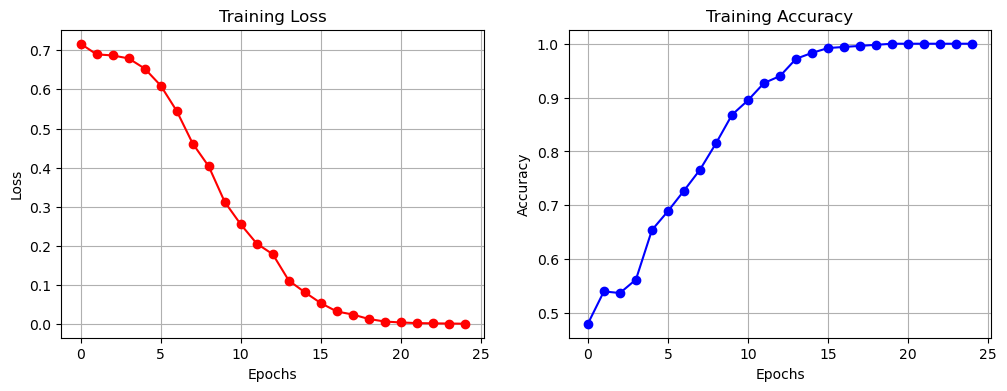


Example Predictions:
Review: 'This movie was an absolute masterpiece. I loved every minute of it.'
Prediction: Positive

Review: 'Terrible script and bad acting. A complete waste of time.'
Prediction: Negative



In [5]:
# --- EVALUATE ON TEST SET ---
model.eval() # Set model to evaluation mode (disables dropout)
test_correct = 0
test_total = 0

# Turn off gradient calculation to save memory and compute
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        outputs = model(batch_X)
        predictions = torch.argmax(outputs, dim=1)
        test_correct += (predictions == batch_y).sum().item()
        test_total += batch_y.size(0)

print(f"\nFinal Test Accuracy: {test_correct / test_total:.4f}")

# --- PLOTTING METRICS ---
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: Training Loss
ax[0].plot(loss_history, color='red', marker='o')
ax[0].set_title('Training Loss')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].grid(True)

# Plot 2: Training Accuracy
ax[1].plot(acc_history, color='blue', marker='o')
ax[1].set_title('Training Accuracy')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy')
ax[1].grid(True)

plt.show()

# --- EXAMPLE PREDICTIONS ---
with torch.no_grad():
    # Define a few custom sentences to test the model
    sample_texts = [
        "This movie was an absolute masterpiece. I loved every minute of it.",
        "Terrible script and bad acting. A complete waste of time."
    ]
    print("\nExample Predictions:")

    for text in sample_texts:
        # Re-apply the exact same preprocessing used on the training data
        tokens = clean_text(text)
        padded_tokens = [word2idx.get(w, 1) for w in tokens][:MAX_LEN]
        padded_tokens += [0] * (MAX_LEN - len(padded_tokens))
        input_tensor = torch.tensor([padded_tokens])

        # Predict
        output = model(input_tensor)
        pred_class = torch.argmax(output, dim=1).item()

        # Map class index back to human-readable label
        sentiment = "Positive" if pred_class == 1 else "Negative"

        print(f"Review: '{text}'")
        print(f"Prediction: {sentiment}\n")

## How Attention Helps the Model:

> Attention mechanisms allow the model to dynamically focus on different parts of the input sequence when making predictions.
<br> Rather than compressing an entire sentence into a rigid hidden state (like traditional RNNs), self-attention computes an alignment score between every word and every other word in the sequence.
<br> In text classification, it allows the model to weigh heavily on important sentiment-bearing words (like "masterpiece" or "terrible") regardless of where they appear in the sentence, while ignoring padding tokens and giving less weight to irrelevant filler words.
<br> Multi-head attention expands this by allowing the model to focus on different linguistic phenomena (e.g., one head might look for sentiment adjectives, while another looks for negation words) simultaneously.